In [1]:
from util import parse_json_file, query_with_macro_state, naive_query
file_path = 'example1.json'  # Path to your JSON file

    # Parse JSON file
parsed_graph, parsed_attributes, parsed_automaton, global_vars = parse_json_file(file_path)
query_with_macro_state(parsed_graph, parsed_attributes, parsed_automaton, 1, 1, global_vars)
# naive_query(parsed_automaton,parsed_graph, global_vars,1,1,parsed_attributes)

From: 1, To: 1, Formula: (assert(and (> age p1)(> p1 10)))
From: 1, To: 2, Formula: (assert(> p1 10))
[And(30 > p1, p1 > ToReal(10))]
[And(p1 <= 29, p1 >= 11), And(25 > p1, p1 > ToReal(10))]
[And(p1 <= 24, p1 >= 11), p1 > ToReal(10)]


[('p1', 11.0, 24.0)]

In [1]:
from z3 import *
a = Real("a")
b = Real("b")
solver = Optimize()
solver.add(a>1.0)
h = solver.minimize(a)
solver.check()
a:z3.ArithRef = solver.lower(h)
EPSILON = a.children()[1]
val = z3.substitute(a, (z3.Const("epsilon", RealSort()), RealVal(0.0001)) )
z3.simplify(val)

10001/10000

In [3]:
from property_graph import generate_and_dump
generate_and_dump(10000, 200, "pgraph/graph-10000-200.json")


         edge:
            {0: [('followanymously', 34), ('follow', 145), ('follow', 195), ('followanymously', 16), ('followanymously', 65), ('favorite', 30), ('follow', 126), ('followanymously', 115), ('favorite', 120), ('followanymously', 166), ('followanymously', 97), ('followanymously', 53), ('favorite', 24), ('followanymously', 124), ('followanymously', 7), ('follow', 99), ('favorite', 110), ('favorite', 155), ('followanymously', 0), ('favorite', 178), ('followanymously', 114), ('favorite', 68), ('followanymously', 58), ('follow', 151), ('favorite', 26), ('follow', 81), ('followanymously', 185), ('favorite', 5), ('favorite', 6), ('followanymously', 190), ('follow', 138), ('favorite', 2), ('followanymously', 189), ('followanymously', 55), ('followanymously', 108), ('followanymously', 173), ('favorite', 135), ('follow', 56), ('favorite', 112), ('followanymously', 193), ('followanymously', 141), ('follow', 59), ('follow', 88), ('followanymously', 158), ('favorite', 162), ('favorite'

Text(0, 0.5, 'Time(s)')

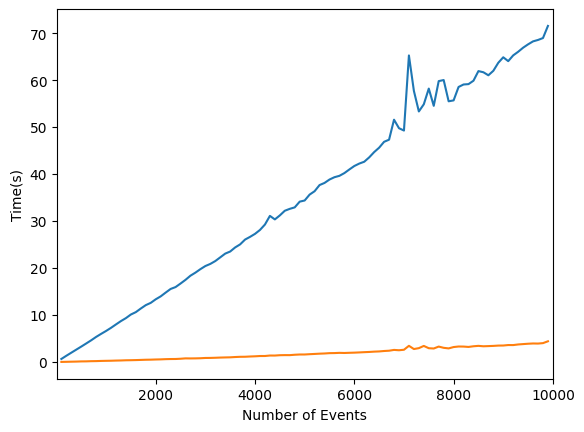

In [17]:
import pickle as pkl
import matplotlib.pyplot as plt 
a = pkl.load(open('sat.pkl', 'rb'))
result = list(map(lambda x:(x[1],x[2]), a))
baseline = list(map(lambda x: x[0]* 100, a))
plt.plot(baseline, result)
plt.xlabel("Number of Events")
plt.xlim((10, 10000))
plt.ylabel("Time(s)")

In [ ]:
from nra_util import query_property_graph
from property_graph import load_graph
from parametric_automata import load_automata

auto = load_automata("pauto/auto1.json")
graph = load_graph("pgraph/graph-10000-200.json")
for i in range(200):
    product_iter = query_property_graph(graph, auto, i)
    print(product_iter)


TypeError: 'bool' object is not iterable

In [48]:
import random
import time  
def generate_real_attribute():
    random.seed(time.clock_gettime_ns(time.CLOCK_THREAD_CPUTIME_ID))
    return random.random() * random.random() * 100

generate_real_attribute()

14.37722586659061